In [ ]:
# https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-machine-learning-tips-and-tricks/

In [1]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
data = np.asarray(pd.read_csv('./data/data.csv', header=None))

In [3]:
# Assign the features to the variable X, and the labels to the variable y. 
X = data[:, 0:2]
y = data[:, 2]

In [4]:
# Use train/test split to split your data 
# Use a test size of 25% and a random state of 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
acc

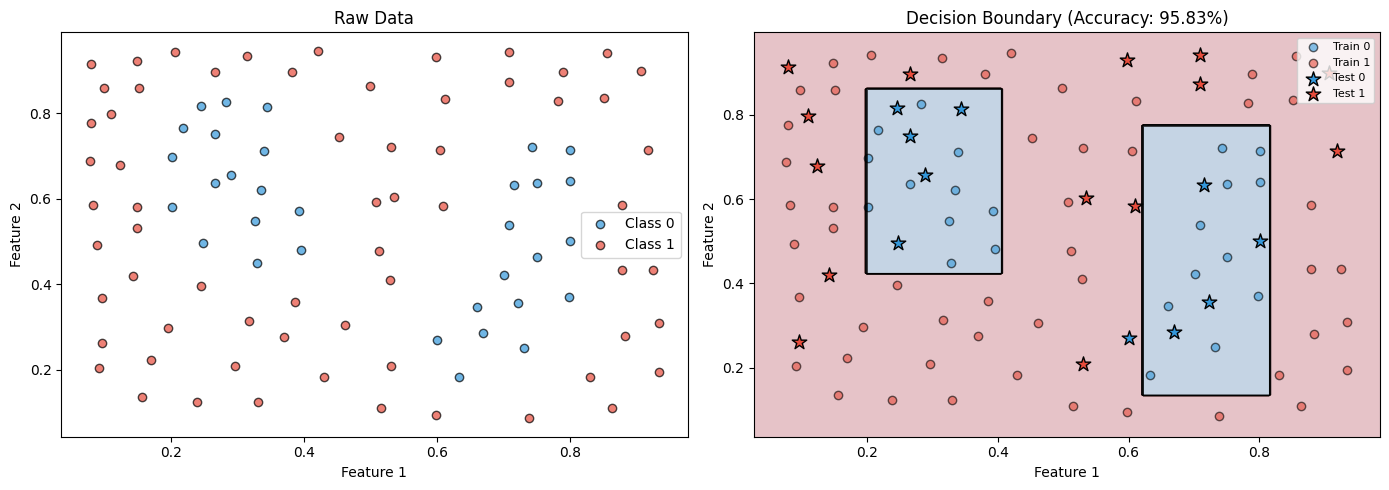

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: raw data ---
ax = axes[0]
ax.scatter(data[data[:, 2] == 0, 0], data[data[:, 2] == 0, 1], c='#3498db', edgecolors='k', label='Class 0', alpha=0.7)
ax.scatter(data[data[:, 2] == 1, 0], data[data[:, 2] == 1, 1], c='#e74c3c', edgecolors='k', label='Class 1', alpha=0.7)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Raw Data')
ax.legend()

# --- Right: decision boundary with train/test split ---
ax = axes[1]

# mesh grid for decision boundary
x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu_r')
ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

# train points (circles)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='#3498db', edgecolors='k', marker='o', label='Train 0',
           alpha=0.6)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='#e74c3c', edgecolors='k', marker='o', label='Train 1',
           alpha=0.6)
# test points (stars)
ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='#3498db', edgecolors='k', marker='*', s=120,
           label='Test 0')
ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='#e74c3c', edgecolors='k', marker='*', s=120,
           label='Test 1')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title(f'Decision Boundary (Accuracy: {acc:.2%})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()